<a href="https://colab.research.google.com/github/Ravalika1129/project/blob/main/Spam_Mail_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [5]:
df = df[['v1','v2']]

df.columns = ['label','message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [6]:
print(df.shape)

print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [7]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [8]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X = vectorizer.fit_transform(df['message'])

y = df['label']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.968609865470852


In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[965   0]
 [ 35 115]]


In [14]:
msg = ["Congratulations! You won a free iPhone."]

msg_vector = vectorizer.transform(msg)

prediction = model.predict(msg_vector)

print(prediction)

[1]


In [15]:
msg = ["Hi Ravalika, class starts at 10 AM."]

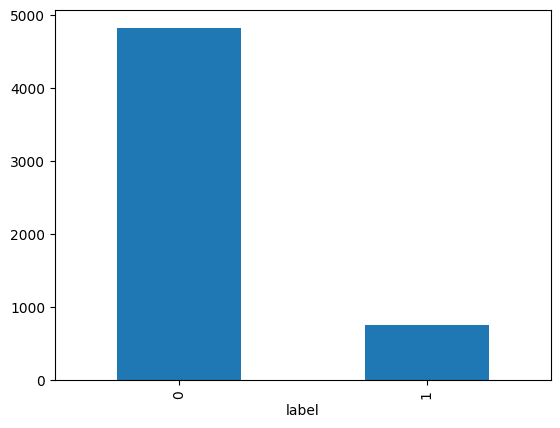

In [16]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='bar'
)

plt.show()